#  **Malaria Supply chain analytics project: Exploratory data analysis**

The purpose of this project is to conduct exploratory data analysis on a provided data set. Our mission is to continue the investigation we began in the step of data preparation and perform further EDA on this data with the aim of learning more about the variables

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import datetime as dt
import seaborn as sns 

In [5]:
df=pd.read_csv('../data/requisitions_cleaned.csv')

In [6]:
df.head()

,product_primary_name,processing_periods_name,facility_type_name,beginning_balance,quantity_received,quantity_dispensed,stock_in_hand,quantity_requested,quantity_approved,total_losses_and_adjustments,amc,pack_size,zone,dispensing_unit
0,PYRA-COMP,2025-05-01,HEALTH CENTER,290.0,22.0,10.0,980.0,NaN,NaN,313,2.0,1,DISTRICT25,TABLET
1,PYRA-COMP,2025-05-01,HEALTH CENTER,3510.0,6.0,437.0,1426.0,NaN,0.0,246,151.0,1,DISTRICT28,TABLET
2,ART-INJ,2025-07-01,HEALTH CENTER,1744.0,4.0,409.0,1508.0,NaN,7396.0,-978,681.0,5,DISTRICT28,VIAL
3,RDT,2025-04-01,HEALTH CENTER,3187.0,737.0,471.0,3934.0,NaN,NaN,345,340.0,25,DISTRICT2,PIECE
4,PYRA-COMP,2025-07-01,HEALTH CENTER,3665.0,0.0,706.0,2667.0,NaN,5338.0,-1042,332.0,1,DISTRICT23,TABLET


## Dealing with missing values

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31742 entries, 0 to 31741
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   product_primary_name          31742 non-null  object 
 1   processing_periods_name       31742 non-null  object 
 2   facility_type_name            31742 non-null  object 
 3   beginning_balance             31742 non-null  float64
 4   quantity_received             31742 non-null  float64
 5   quantity_dispensed            31742 non-null  float64
 6   stock_in_hand                 31742 non-null  float64
 7   quantity_requested            8751 non-null   float64
 8   quantity_approved             25782 non-null  float64
 9   total_losses_and_adjustments  31742 non-null  int64  
 10  amc                           31742 non-null  float64
 11  pack_size                     31742 non-null  int64  
 12  zone                          31742 non-null  object 
 13  d

Event though the df.info() does not show missing values, we can observe that the columns **quantity_requested** 
and **quantity_approved** have missing values. 
* As explained during the data preparation phase, this is not necessarily a data quality issue.
It could be instead business logic related issue. eg. The NaN or empty values in the quantityrequested means that the facility did not place an order and the associated quantityapproved could also be empty if the approval team is OK with the decision
* However it could be a data quality issue if the quantityrequested is not empty and the quantityapproved is empty. But for keeping things simple we will consider that the NaN is quantityapproved means 0 since Pandas functions handle NaN properly: `sum()` and `means()` ignores NaN 

In [8]:
df.describe()

,beginning_balance,quantity_received,quantity_dispensed,stock_in_hand,quantity_requested,quantity_approved,total_losses_and_adjustments,amc,pack_size
count,31742.000000,31742.000000,31742.000000,31742.000000,8751.000000,25782.000000,31742.000000,31742.000000,31742.000000
mean,1174.268288,202.350387,305.365604,1136.714133,762.121815,827.806415,-4.943009,253.131214,184.765957
std,1449.199817,470.726527,352.912528,1372.235556,498.749318,2034.067923,428.530698,352.885664,366.273133
min,0.000000,0.000000,0.000000,1.000000,17.000000,0.000000,-1903.000000,0.000000,1.000000
25%,203.000000,0.000000,62.000000,201.000000,398.000000,1.000000,-293.000000,28.000000,5.000000
50%,662.000000,17.000000,185.000000,660.000000,654.000000,44.000000,-4.000000,119.000000,30.000000
75%,1592.000000,170.000000,425.000000,1565.000000,1009.000000,607.000000,285.000000,339.000000,50.000000
max,19998.000000,7090.000000,4337.000000,16988.000000,4061.000000,52652.000000,1719.000000,4327.000000,1000.000000


## Data visualization

We will use data visualization to understand their distributions and assess them

### Beginning Balance

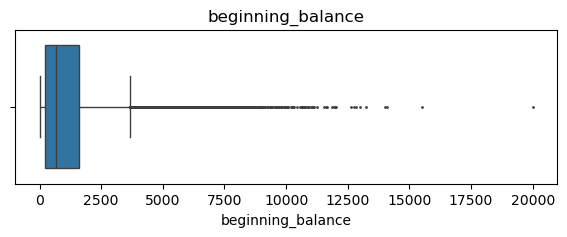

In [9]:
# Create box plot of beginning_balance
plt.figure(figsize=(7,2))
plt.title('beginning_balance')
sns.boxplot(data=None, x=df['beginning_balance'], fliersize=1);

#### Quantification of the outliers detection

In [10]:
percentile75=1592
percentile25=203
IQR=percentile75-percentile25
upper_limit = percentile75 + 1.5 * IQR
lower_limit = percentile25 - 1.5 * IQR
print ('Outlier threshold upper limit',upper_limit)
print('Outlier threshold lower limit',lower_limit)

Outlier threshold upper limit 3675.5
Outlier threshold lower limit -1880.5


* The distribution of beginning_balance exhibits a strong right-skewed pattern, indicating that stock levels are not evenly distributed across observations. Based on the descriptive statistics, the interquartile range (IQR) lies approximately between 203 (25th percentile) and 1592 (75th percentile), with a median of 662 units. This suggests that at least 50% of facilities begin the reporting period with stock levels between ~200 and ~1,600 units.
* However, the presence of extreme values extending up to ~20,000 units—far beyond the upper quartile—creates a pronounced long right tail. From a purely statistical perspective, these would be classified as outliers as the value is > 3675.5 (Upper limit). In the dataset, a significant number of observations exceed this threshold, confirming the heavy-tailed distribution and a real concerns to treat them as outliers
* From a supply chain perspective, these high values should not be interpreted as anomalies by default. Instead, they reflect structural heterogeneity within the system. Facilities operate at different levels (e.g., health centers vs. district or regional hospitals), leading to substantial variation in stockholding capacity. Products are distributed in different dispensing units and pack sizes, ranging from small units (e.g., blister packs of 30 tablets) to bulk formats (e.g., cartons containing up to 1000 tablets). As a result, identical “quantities” in reporting terms may correspond to vastly different physical volumes, inflating values for certain products.

**Outliers in this dataset are STRUCTURAL, not necessarily ERRORS**

Given that quantities are expressed in dispensing units (e.g., tablets, vials, pieces), a more appropriate approach is to analyze outliers within homogeneous groups defined by product, dispensing unit, and facility type.

#### Outlier detection by category

In [11]:
df_product_dispensingunit_unique = df[['product_primary_name', 'dispensing_unit','pack_size']].drop_duplicates().reset_index(drop=True)
df_product_dispensingunit_unique

,product_primary_name,dispensing_unit,pack_size
0,PYRA-COMP,TABLET,1
1,ART-INJ,VIAL,5
2,RDT,PIECE,25
3,ACT-GC,BLISTER,30
4,ACT-SC,BLISTER,30
5,QUIN,TABLET,1000
6,SP,TABLET,1000
7,ACT-AD,BLISTER,30
8,ART-SUP,CAPSULE,2
9,PYRA-SAC,SACHET,1


Based on the recommendation above we will analyze the outlier by products group of similar dispensing unit, groups (therapeutic group) within different by facilities type.
Products will be group below based on they homogeneity:
* ACT-INF,ACT-SC,ACT-GC,ACT-AD: group of product for the treatment of uncomplicated Malaria using the same dispensing units. This group will be called Group ACT
* PYRA-COMP,PYRA-SAC: Group of product for the treatment of uncomplicated Malaria even though they don't use the same dispensing units by their packsize are the same.  This group will be called Group PYRA
* ART-INJ,ART-SUP: Both forms are used for treating severe malaria, although they serve different roles in the treatment process. Their dispensing unit are similar. This group will be called Group ART
* QUIN and SP: Even though they used for treatment of different type of malaria (Severe and uncomplicated/prevention) they use the same dispensing unit and they have the same packsize). This group will be called Group SP
* ITN and RDT: are used respectively for prevention and diagnosis of malaria. As they are not treatment and use the same dispensing unit we will group them. This group will be called Group PREV

##### Outliers analyis of Group ACT products

<Axes: xlabel='product_primary_name', ylabel='beginning_balance'>

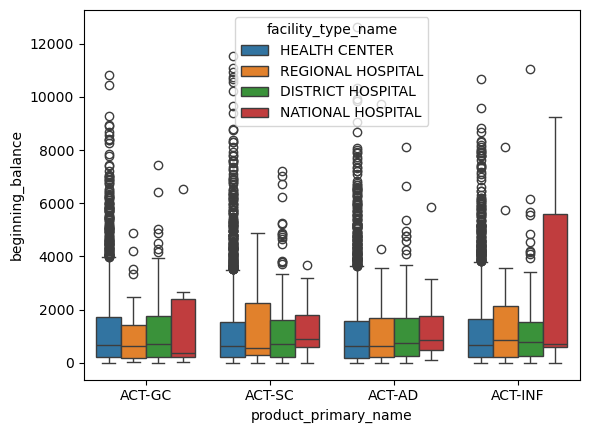

In [13]:
group_act=['ACT-INF','ACT-SC','ACT-GC','ACT-AD']
df_group=df[df['product_primary_name'].isin(group_act)]
sns.boxplot(
    data=df_group,
    x="product_primary_name",
    y="beginning_balance",
    hue="facility_type_name"
)

In [24]:
def compute_percentiles(df, facility_type, column='beginning_balance'):
    df_subset = df[df['facility_type_name'] == facility_type]
    p25 = df_subset[column].quantile(0.25)
    p75 = df_subset[column].quantile(0.75)
    iqr = p75 - p25
    upper = p75 + 1.5 * iqr
    lower = p25 - 1.5 * iqr
    nb_upper_outliers=len(df_subset[df_subset[column]>upper])
    total_number_obs=df_subset.shape[0]
    #print('Number of outlier',nb_upper_outliers)
    #print('total number',total_number_obs)
    proportion_outliers=(nb_upper_outliers/total_number_obs)*100
    return {
        'facility_type': facility_type,
        'p25': p25,
        'p75': p75,
        'iqr': iqr,
        'upper_limit': upper,
        'lower_limit': lower,
        'nb_outlier': nb_upper_outliers,
        'tot_observations': total_number_obs,
        'proportion_outliers': proportion_outliers,
        
    }

In [25]:
results = []
for ft in df_group['facility_type_name'].unique():
    res = compute_percentiles(df_group, ft)
    results.append(res)
#results
df_results = pd.DataFrame(results)
df_results

,facility_type,p25,p75,iqr,upper_limit,lower_limit,nb_outlier,tot_observations,proportion_outliers
0,HEALTH CENTER,199.00,1605.25,1406.25,3714.625,-1910.375,603,9800,6.153061
1,REGIONAL HOSPITAL,197.25,1885.50,1688.25,4417.875,-2335.125,5,150,3.333333
2,DISTRICT HOSPITAL,230.00,1637.75,1407.75,3749.375,-1881.625,43,618,6.957929
3,NATIONAL HOSPITAL,359.25,2243.50,1884.25,5069.875,-2467.125,4,54,7.407407


* The distribution of beginning stock levels reveals distinct patterns across facility types. 
* The lower threshold are negative and therefore not operationally meaningful given that stock cannot be negative
  
**Health centers**
* Health centers exhibit a moderate level of outliers (~5.6%), with extreme values appearing highly concentrated within a narrow range. This Similar deviation pattern across health centers suggests a consistent and systematic deviation from expected stock levels, likely driven by uniform supply practices: Systematic over-allocation at a similar scale, uniform policy misapplication at the facility level concerning the ordering and usage of products or a centralized supply decision of certain quantities of products applied uniformly.
* From a statistical perspective, the clustering of outliers suggests low variability among extreme values, meaning that when overstocking occurs, it tends to happen at a similar magnitude across many health centers.
  
**Regional Hospital**
* Regional hospitals present the lowest proportion of outliers (~3.3%), indicating that most facilities operate within expected stock ranges. However, the outliers that do exist are more dispersed, reflecting greater variability in extreme values.
* This dispersion indicates that stock imbalances at these levels are less uniform. Statistically, this suggests better central tendency control (fewer outliers). From a supply chain perspective, this indicates Generally better alignment between supply and demand comparing to other facility types
  
**District hospital**
* District hospitals exhibit a higher proportion of outliers (~6.9%), combined with a moderately dispersed pattern of extreme values. This indicates that deviations from expected stock levels are both frequent and variable.
* Statistically this means that outliers are more numerous than in health centers and regional hospitals
* From a supply chain perspective, this could reflect Inconsistent stock management practices across districts, uneven allocation of stock relative to demand and limited enforcement of stock control policies.
* Unlike health centers, where inefficiencies are uniform, district hospitals show heterogeneous inefficiencies, suggesting that some facilities manage stock effectively while accumulating significant excess.

**National hospital**
* National hospitals show the highest proportion of outliers (~7.4%), with widely scattered extreme values reaching the highest levels in the system. This indicates that stock imbalances are both frequent and highly variable.
* From a supply chain perspective, this reveals that significant deviations from intended system design, Weak control over stock allocation and inventory limits and Accumulation of excess stock.


##### Outliers analyis of Group PYRA

<Axes: xlabel='product_primary_name', ylabel='beginning_balance'>

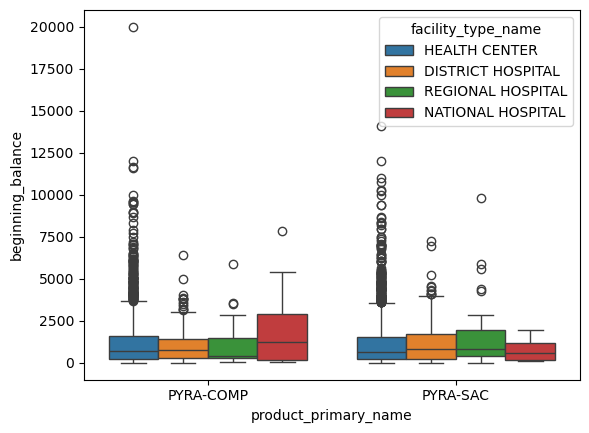

In [27]:
group_product=['PYRA-COMP','PYRA-SAC']
df_group=df[df['product_primary_name'].isin(group_product)]
sns.boxplot(
    data=df_group,
    x="product_primary_name",
    y="beginning_balance",
    hue="facility_type_name"
)

In [28]:
results = []
for ft in df_group['facility_type_name'].unique():
    res = compute_percentiles(df_group, ft)
    results.append(res)
#results
df_results = pd.DataFrame(results)
df_results

,facility_type,p25,p75,iqr,upper_limit,lower_limit,nb_outlier,tot_observations,proportion_outliers
0,HEALTH CENTER,204.0,1576.00,1372.00,3634.000,-1854.000,287,4717,6.084376
1,DISTRICT HOSPITAL,235.0,1673.00,1438.00,3830.000,-1922.000,16,321,4.984424
2,REGIONAL HOSPITAL,263.0,1719.75,1456.75,3904.875,-1922.125,6,76,7.894737
3,NATIONAL HOSPITAL,154.0,2106.00,1952.00,5034.000,-2774.000,2,24,8.333333


**Health Centers**
For health centers, approximately 6.1% of observations are outliers,almost equal to the ACT group. This confirms that overstocking remains a systemic issue, not limited to a specific product category. Outliers remain highly concentrated, similar to the ACT group, indicating systematic and repeated over-allocation patterns and uniform supply behavior across facilities, with limited adaptation to actual consumption levels.

**District Hospitals**
For district hospitals, approximately 5.0% of observations are outliers, slightly lower than in the ACT group (6.9%). This suggests a relatively better control of stock levels for the PYRA group compared to ACTs, although inefficiencies persist. Outliers are moderately dispersed, similar to the ACT group but with slightly less frequency, indicating partial alignment between supply and demand and inconsistent implementation of stock management practices across facilities.

**Regional Hospitals**
For regional hospitals, approximately 7.9% of observations are outliers, significantly higher than in the ACT group (3.3%). This indicates that the PYRA group experiences greater instability in stock management at this level. Outliers are more scattered, consistent with the ACT pattern but more pronounced, reflecting increased variability and weaker control of inventory levels, likely driven by irregular supply patterns or planning inaccuracies.

**National Hospitals**
For national hospitals, approximately 8.3% of observations are outliers, higher than in the ACT group and the highest across all facility types. This suggests that inefficiencies are more amplified for the PYRA group at this level. Outliers are widely dispersed and reach extreme values, similar to the ACT group but more pronounced, indicating significant variability and weak alignment between supply and consumption, driven by system-level imbalances and insufficient control of stock allocation.

##### Outliers analyis of Group ART

<Axes: xlabel='product_primary_name', ylabel='beginning_balance'>

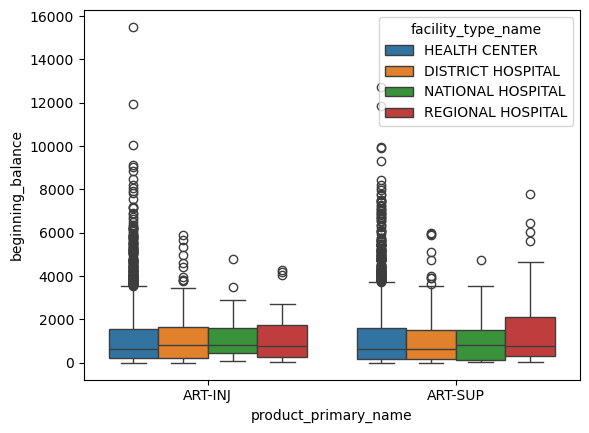

In [29]:
group_product=['ART-INJ','ART-SUP']
df_group=df[df['product_primary_name'].isin(group_product)]
sns.boxplot(
    data=df_group,
    x="product_primary_name",
    y="beginning_balance",
    hue="facility_type_name"
)

In [30]:
results = []
for ft in df_group['facility_type_name'].unique():
    res = compute_percentiles(df_group, ft)
    results.append(res)
#results
df_results = pd.DataFrame(results)
df_results

,facility_type,p25,p75,iqr,upper_limit,lower_limit,nb_outlier,tot_observations,proportion_outliers
0,HEALTH CENTER,198.00,1577.00,1379.0,3645.50,-1870.50,307,4901,6.264028
1,DISTRICT HOSPITAL,211.00,1584.00,1373.0,3643.50,-1848.50,19,330,5.757576
2,NATIONAL HOSPITAL,298.00,1541.00,1243.0,3405.50,-1566.50,4,29,13.793103
3,REGIONAL HOSPITAL,271.75,1796.75,1525.0,4084.25,-2015.75,7,74,9.459459


**Health Centers**
For health centers, approximately 6.3% of observations are outliers, slightly higher than in the ACT group. This confirms that overstocking remains a systemic issue, consistent across different product categories. Outliers remain highly concentrated, similar to the ACT group, indicating systematic and repeated over-allocation patterns and uniform supply behavior across facilities, with limited adjustment to actual consumption needs.

**District Hospitals**
For district hospitals, approximately 5.8% of observations are outliers, slightly lower than in the ACT group. This suggests a moderate level of control in stock management, comparable to ACT products but with slightly improved alignment between supply and demand. Outliers are moderately dispersed, similar to the ACT group, indicating partial consistency in supply practices, though some variability persists across facilities.

**Regional Hospitals**
For regional hospitals, approximately 9.5% of observations are outliers, significantly higher than in the ACT group. This indicates that the ART group experiences greater instability in stock management at this level. Outliers are more scattered and reach higher values, consistent with the ACT pattern but more pronounced, reflecting increased variability and weaker control of inventory levels, likely driven by irregular supply flows or planning inconsistencies.

**National Hospitals**
For national hospitals, approximately 13.8% of observations are outliers, substantially higher than in the ACT group and the highest among all facility types. This indicates strong amplification of inefficiencies for ART products at this level. Outliers are widely dispersed and extreme, exceeding those observed in the ACT group, reflecting significant variability and weak alignment between supply and actual consumption, driven by system-level imbalances and insufficient control over stock allocation.

##### Outliers analyis of Group SP

<Axes: xlabel='product_primary_name', ylabel='beginning_balance'>

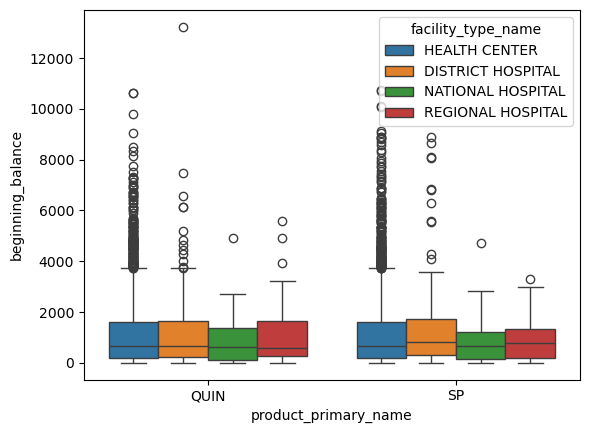

In [31]:
group_product=['QUIN','SP']
df_group=df[df['product_primary_name'].isin(group_product)]
sns.boxplot(
    data=df_group,
    x="product_primary_name",
    y="beginning_balance",
    hue="facility_type_name"
)

In [32]:
results = []
for ft in df_group['facility_type_name'].unique():
    res = compute_percentiles(df_group, ft)
    results.append(res)
#results
df_results = pd.DataFrame(results)
df_results

,facility_type,p25,p75,iqr,upper_limit,lower_limit,nb_outlier,tot_observations,proportion_outliers
0,HEALTH CENTER,197.25,1611.00,1413.75,3731.625,-1923.375,343,4906,6.991439
1,DISTRICT HOSPITAL,279.00,1714.00,1435.00,3866.500,-1873.500,22,311,7.073955
2,NATIONAL HOSPITAL,90.50,1358.50,1268.00,3260.500,-1811.500,2,31,6.451613
3,REGIONAL HOSPITAL,235.75,1401.25,1165.50,3149.500,-1512.500,5,76,6.578947


**Health Centers**
For health centers, approximately 7.0% of observations are outliers, higher than in the ACT group. This indicates that overstocking is more pronounced for the SP group at this level, reinforcing the presence of systemic inefficiencies across product categories. Outliers remain highly concentrated, similar to the ACT group, indicating systematic and repeated over-allocation patterns and uniform supply behavior across facilities, with limited adjustment to actual consumption.

**District Hospitals**
For district hospitals, approximately 7.1% of observations are outliers, higher than in the ACT group. This suggests that stock management for the SP group is less controlled compared to ACT products. Outliers are moderately dispersed, similar to the ACT group but more frequent, indicating greater variability and weaker alignment between supply and demand, with inconsistencies in the implementation of stock management practices across facilities.

**Regional Hospitals**
For regional hospitals, approximately 6.6% of observations are outliers, slightly higher than in the ACT group. This indicates that inefficiencies persist at this level, although less pronounced than for district hospitals. Outliers are scattered, consistent with the ACT group, reflecting variability in stock levels and moderate instability in inventory control, likely driven by uneven supply patterns.

**National Hospitals**
For national hospitals, approximately 6.5% of observations are outliers, comparable to or slightly higher than in the ACT group. This suggests that stock management for the SP group remains unstable at this level, though less extreme than observed for the ART group. Outliers are widely dispersed, similar to the ACT group, indicating persistent variability and weak alignment between supply and consumption, driven by system-level inefficiencies rather than operational necessity.

##### Outliers analyis of Group PREV

<Axes: xlabel='product_primary_name', ylabel='beginning_balance'>

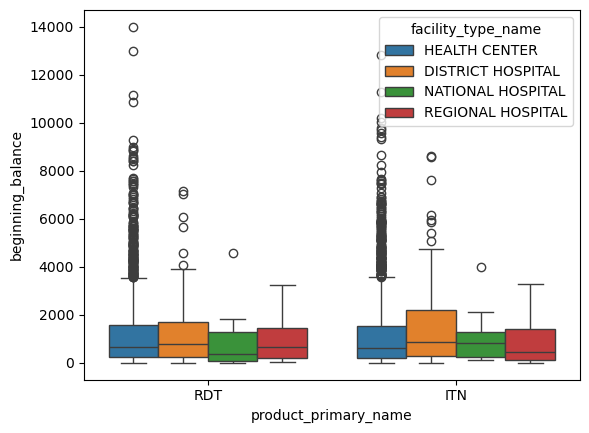

In [33]:
group_product=['ITN','RDT']
df_group=df[df['product_primary_name'].isin(group_product)]
sns.boxplot(
    data=df_group,
    x="product_primary_name",
    y="beginning_balance",
    hue="facility_type_name"
)

In [34]:
results = []
for ft in df_group['facility_type_name'].unique():
    res = compute_percentiles(df_group, ft)
    results.append(res)
#results
df_results = pd.DataFrame(results)
df_results

,facility_type,p25,p75,iqr,upper_limit,lower_limit,nb_outlier,tot_observations,proportion_outliers
0,HEALTH CENTER,197.0,1548.5,1351.5,3575.75,-1830.25,316,4867,6.492706
1,DISTRICT HOSPITAL,262.0,1864.0,1602.0,4267.00,-2141.00,19,349,5.444126
2,NATIONAL HOSPITAL,191.0,1280.0,1089.0,2913.50,-1442.50,2,29,6.896552
3,REGIONAL HOSPITAL,176.0,1438.5,1262.5,3332.25,-1717.75,0,79,0.000000


**Health Centers**
For health centers, approximately 6.5% of observations are outliers, slightly higher than in the ACT group. This indicates that overstocking persists across diagnostic and preventive products, confirming that inefficiencies are not limited to treatment commodities. Outliers remain highly concentrated, similar to the ACT group, indicating systematic and repeated over-allocation patterns and uniform supply behavior across facilities, with limited adaptation to actual utilization patterns.

**District Hospitals**
For district hospitals, approximately 5.4% of observations are outliers, slightly lower than in the ACT group. This suggests a moderate level of control in stock management, with relatively better alignment between supply and demand for PREV products compared to ACTs. Outliers are moderately dispersed, similar to the ACT group, indicating partial consistency in supply practices, although some variability remains across facilities.

**Regional Hospitals**
For regional hospitals, approximately 0.0% of observations are outliers, significantly lower than in the ACT group. This indicates a high level of control and stability in stock management for PREV products at this level. The absence of outliers suggests that stock levels are consistently maintained within expected operational ranges, reflecting better alignment between supply and consumption and more effective inventory management practices compared to other product groups.

**National Hospitals**
For national hospitals, approximately 6.9% of observations are outliers, comparable to or slightly higher than in the ACT group. This indicates that variability and inefficiencies persist at this level even for PREV products. Outliers are widely dispersed, similar to the ACT group, reflecting continued misalignment between supply and actual utilization, driven by system-level inefficiencies rather than product-specific factors.

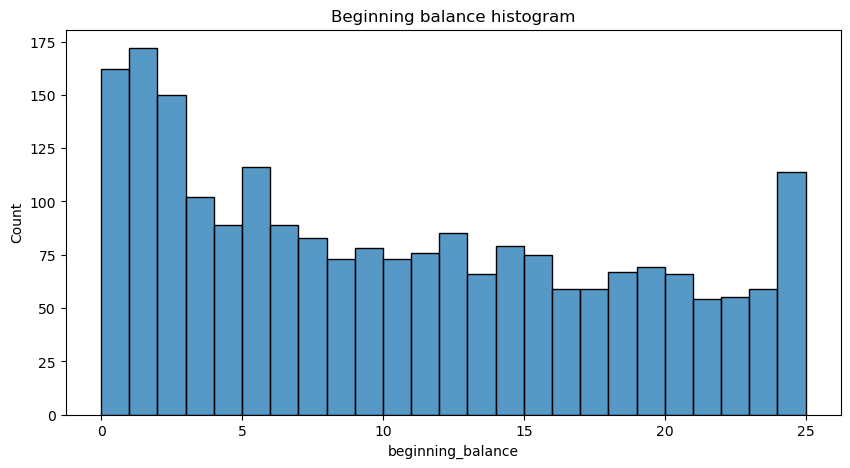

In [7]:
# Create the histogram of beginning_balance
plt.figure(figsize=(10,5))
sns.histplot(df['beginning_balance'], bins=range(0,26,1))
plt.title('Beginning balance histogram');